# Biomedical Insurance Cost Predictor (Artificial Neural Network) - Insurance dataset

### 1) Import Libraries

In [33]:
# Import libraries and modules

# ---------- path setup ----------
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent.parent.parent
sys.path.insert(0, str(PROJECT_ROOT / "Notebooks"))
DATA_DIR = PROJECT_ROOT / "Data/insurance_dataset"

#----- Tools, visualizers -----
from utils import *
import pandas as pd
import scipy.stats
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib
import shap

#----- Preprocessing, Neural Networks -----
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    root_mean_squared_error
)
import tensorflow as tf

#----- Variables -----
RANDOM_STATE = 42



### 2) Load Data

In [24]:
# Load train set
#---------------
data = pd.read_csv(DATA_DIR / "insurance_train_set.csv")
test = pd.read_csv(DATA_DIR / "insurance_test_set.csv")

data.shape, test.shape

((1137, 7), (201, 7))

#### About handling invalid values
Since the dataset at hand is already clean and there are no missing & invalid values, We do not perform this stage in this notebook.

### 3) Define feature columns and target & Split
> Target: charges

#### - Define features & target

In [25]:
"""
Separate features and target for the regression task.

- Target: `charges`
- Features: all columns except `charges`

"""

# -------------------------------------
# charges as the target
# -------------------------------------

# ---------- DATA ---------

# Separate features and labels cols
X_TRAIN = data.drop(columns=['charges']) # Features
y_train = data['charges'] # Labels


# ---------- TEST ---------

# Separate features and labels cols
X_TEST = test.drop(columns=['charges']) # Features
y_test = test['charges'] # Labels


# Display shapes
print("----- DONE -----", end='\n\n')
print(f"Shapes:\n\nX_TRAIN: {X_TRAIN.shape} | y_train: {y_train.shape}")
print(f"X_TEST: {X_TEST.shape} | y_test: {y_test.shape}")


----- DONE -----

Shapes:

X_TRAIN: (1137, 6) | y_train: (1137,)
X_TEST: (201, 6) | y_test: (201,)


#### - Split (train set - val set)

In [26]:
X_train, X_val, y_train, y_val = train_test_split(
    X_TRAIN,
    y_train,
    test_size=0.15,
    random_state=RANDOM_STATE
)

print("---- Done ----")
print(f"X_train: {X_train.shape} | X_val: {X_val.shape} | y_train: {y_train.shape} | y_val: {y_val.shape}")

---- Done ----
X_train: (966, 6) | X_val: (171, 6) | y_train: (966,) | y_val: (171,)


### 4) Core Feature Engineering

#### 1- Feature columns (except target)

In [27]:

# Experiment 1
def smoking_interaction_features(X):
    # Make a copy of X
    x = X.copy()

    # Binarize smoker col - Temporary
    smoker_num = x['smoker'].map({'no': 0, 'yes': 1}) 

    # Build obesity feature that's needed for high_risk feature - temporary
    x['obesity'] = np.where(x['bmi'] >= 30, 1, 0)

    # Build smoker related features
    x['bmi_smoker'] = x['bmi'] * smoker_num
    x['age_smoker'] = x['age'] * smoker_num
    x['high_risk'] = x['obesity'] * smoker_num

    # Drop obesity col
    x.drop(columns=['obesity'], inplace=True)

    return x

# Expriment 2
def bmi_age_related_features(X):
    # Make a copy of X
    x = X.copy()

    # Build bmi/age related features
    x['bmi_age'] = x['age'] * x['bmi']
    x['obesity'] = np.where(x['bmi'] >= 30, 1, 0)
    x['severe_obesity'] = np.where(x['bmi'] >= 35, 1, 0)

    return x

# Experiment 3
def all_eng_featured_combined(X):
    # Make a copy of X
    x = X.copy()

    # Binarize smoker col - Temporary
    smoker_num = x['smoker'].map({'no': 0, 'yes': 1})

    # Build bmi/age related features
    x['bmi_age'] = x['age'] * x['bmi']
    x['obesity'] = np.where(x['bmi'] >= 30, 1, 0)
    x['severe_obesity'] = np.where(x['bmi'] >= 35, 1, 0)

    # Build smoker related features
    x['bmi_smoker'] = x['bmi'] * smoker_num
    x['age_smoker'] = x['age'] * smoker_num
    x['high_risk'] = x['obesity'] * smoker_num

    return x


# Apply smoker related eng
x_smoker_train = smoking_interaction_features(X_train)
x_smoker_val = smoking_interaction_features(X_val)
x_smoker_test = smoking_interaction_features(X_TEST)

# Apply bmi/age related eng
x_bmi_age_train = bmi_age_related_features(X_train)
x_bmi_age_val = bmi_age_related_features(X_val)
x_bmi_age_test = bmi_age_related_features(X_TEST)

# Apply all features eng
x_all_train = all_eng_featured_combined(X_train)
x_all_val = all_eng_featured_combined(X_val)
x_all_test = all_eng_featured_combined(X_TEST)


print("----- Feature Engineering Done -----")


----- Feature Engineering Done -----


In [8]:
# Check basekine
X_train.head(5)

,age,sex,bmi,children,smoker,region
1055,30,female,30.90,3,no,southwest
1035,64,male,26.41,0,no,northeast
78,50,male,37.07,1,no,southeast
192,26,male,23.70,2,no,southwest
536,57,male,42.13,1,yes,southeast


In [21]:
# Check ex1
x_smoker_train.head(5)

,age,sex,bmi,children,smoker,region,bmi_smoker,age_smoker,high_risk
1055,30,female,30.90,3,no,southwest,0.00,0,0
1035,64,male,26.41,0,no,northeast,0.00,0,0
78,50,male,37.07,1,no,southeast,0.00,0,0
192,26,male,23.70,2,no,southwest,0.00,0,0
536,57,male,42.13,1,yes,southeast,42.13,57,1


In [22]:
# Check ex2
x_bmi_age_train.head(5)

,age,sex,bmi,children,smoker,region,bmi_age,obesity,severe_obesity
1055,30,female,30.90,3,no,southwest,927.00,1,0
1035,64,male,26.41,0,no,northeast,1690.24,0,0
78,50,male,37.07,1,no,southeast,1853.50,1,1
192,26,male,23.70,2,no,southwest,616.20,0,0
536,57,male,42.13,1,yes,southeast,2401.41,1,1


In [23]:
# Check ex3
x_all_train.head(5)

,age,sex,bmi,children,smoker,region,bmi_age,obesity,severe_obesity,bmi_smoker,age_smoker,high_risk
1055,30,female,30.90,3,no,southwest,927.00,1,0,0.00,0,0
1035,64,male,26.41,0,no,northeast,1690.24,0,0,0.00,0,0
78,50,male,37.07,1,no,southeast,1853.50,1,1,0.00,0,0
192,26,male,23.70,2,no,southwest,616.20,0,0,0.00,0,0
536,57,male,42.13,1,yes,southeast,2401.41,1,1,42.13,57,1


##### -  A quick sanity check and EDA for new features

In [9]:
all_new_num = ['bmi_smoker', 'age_smoker', 'bmi_age']

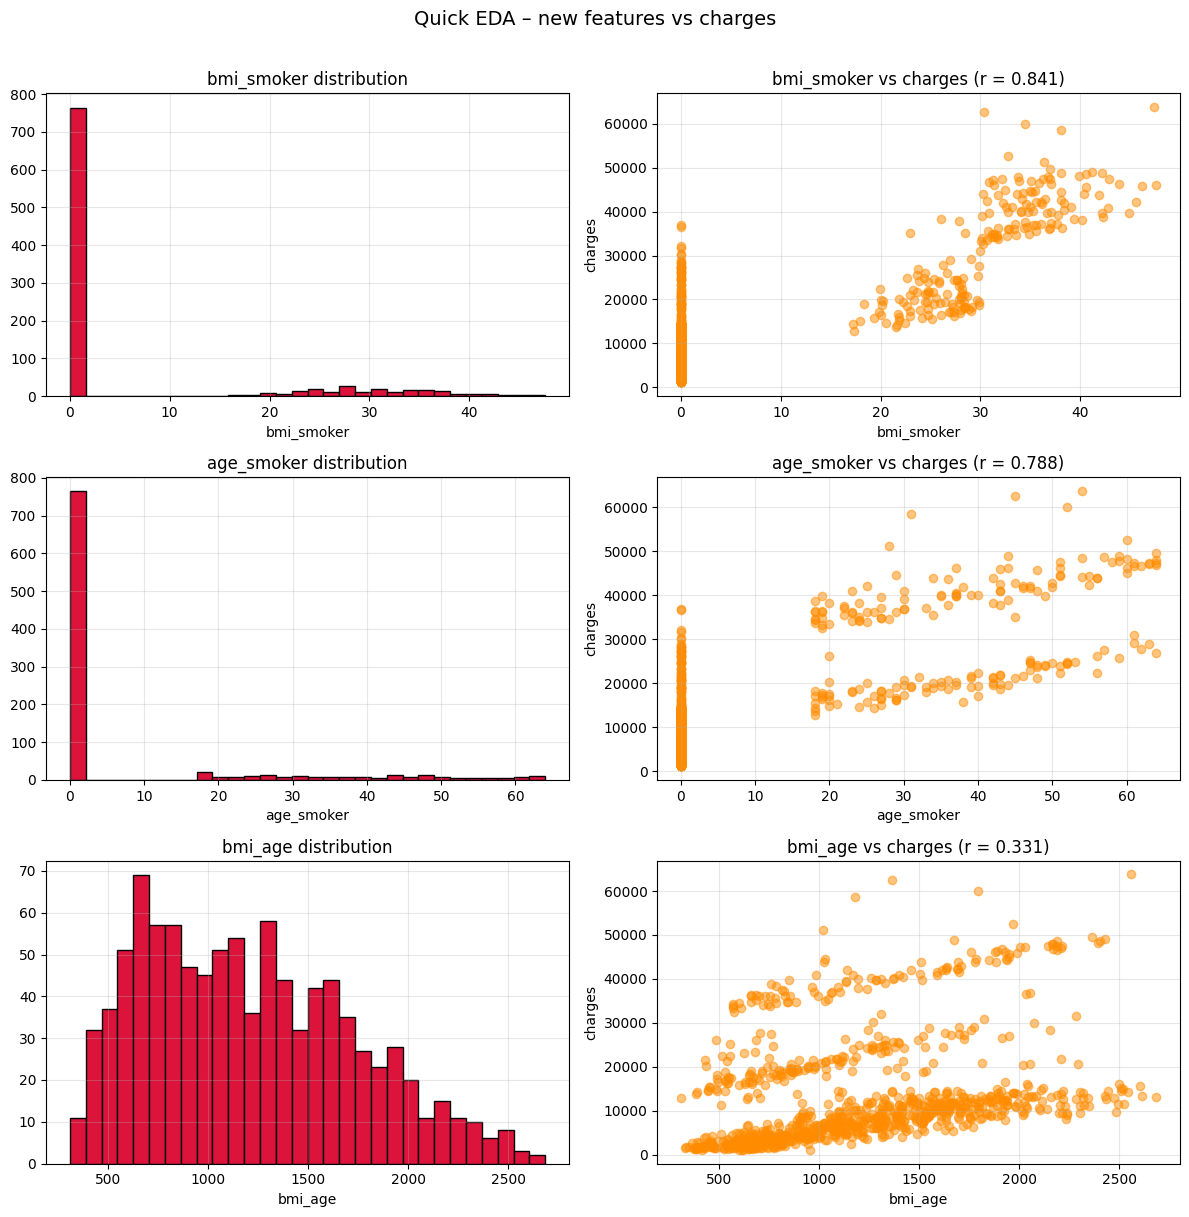

In [25]:
# Quick EDA on the numeric features
# ---------------------------------------------
def plot_features_eda(X, y, features, target_name, hist_c, scat_c, ncols=2):
    """
    For each feature in `features`, create a row with two subplots:
    histogram of the feature (left) and scatter vs target (right).
    """
    nrows = len(features)
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows))
    
    # Make sure axes is 2D even for a single row
    if nrows == 1:
        axes = axes.reshape(1, -1)
    
    for i, feat in enumerate(features):
        r, _ = scipy.stats.pearsonr(X[feat], y)
        
        # Histogram
        axes[i, 0].hist(X[feat], bins=30, color=hist_c, edgecolor='k')
        axes[i, 0].set_title(f'{feat} distribution')
        axes[i, 0].set_xlabel(feat)
        axes[i, 0].grid(alpha=0.3)
        
        # Scatter
        axes[i, 1].scatter(X[feat], y, alpha=0.5, color=scat_c)
        axes[i, 1].set_title(f'{feat} vs {target_name} (r = {r:.3f})')
        axes[i, 1].set_xlabel(feat)
        axes[i, 1].set_ylabel(target_name)
        axes[i, 1].grid(alpha=0.3)
    
    plt.suptitle(f'Quick EDA – new features vs {target_name}', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()


plot_features_eda(x_all_train, y_train, all_new_num,
                  'charges', 'crimson', 'darkorange')



In [10]:
all_new_cat = ['obesity', 'severe_obesity', 'high_risk']

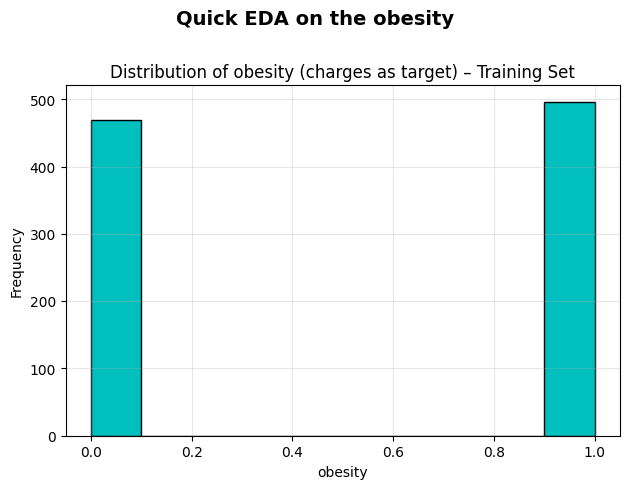

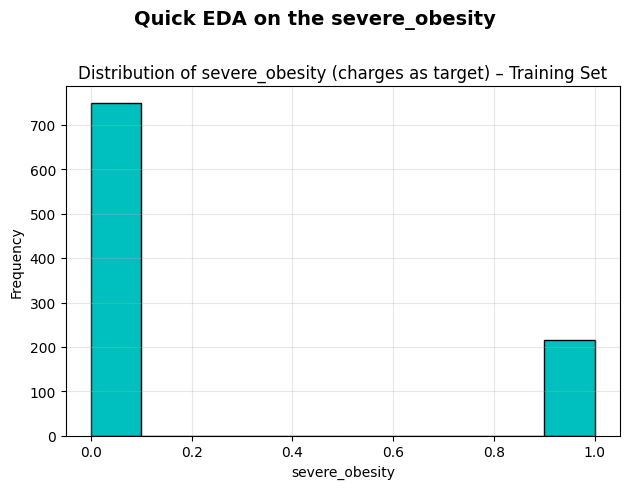

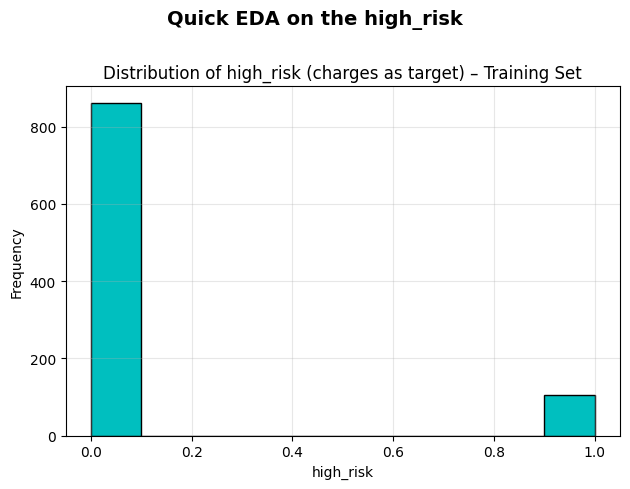

In [27]:
def plot_cat_dis(X, feat):
    # Histogram of new cat features (training set)
    X[feat].hist(color='c', edgecolor='k')
    plt.title(f'Distribution of {feat} (charges as target) – Training Set')
    plt.xlabel(feat)
    plt.ylabel('Frequency')
    plt.grid(alpha=0.3)


    plt.suptitle(f"Quick EDA on the {feat}", fontsize=14, weight='bold' ,y=1.01)
    plt.tight_layout()
    plt.show()


for f in all_new_cat:
    plot_cat_dis(x_all_train, f)

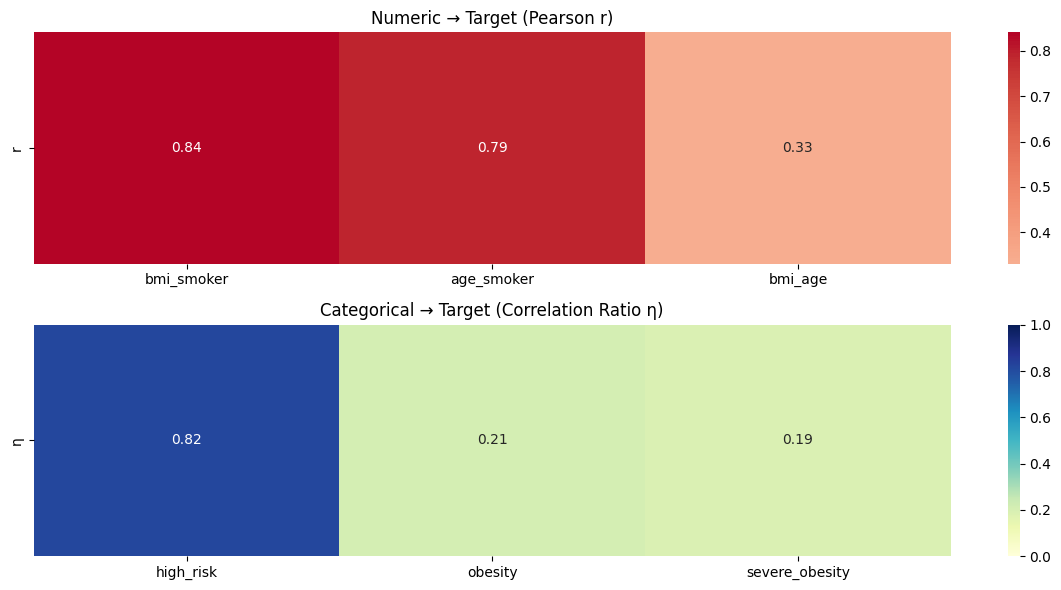

In [28]:
full_train_ana = x_all_train.copy()
full_train_ana['charges'] = y_train.values

# Now pass them to the analyzer
analyzer_all = CorrelationAnalyzer(
    data=full_train_ana,
    target_type='numeric',
    num_cols=all_new_num,
    cat_cols=all_new_cat,
    target_col='charges'
)

analyzer_all.plot_feature_numeric_target()

#### 2- Target column
- We'll apply log-transformer on the target to address it being right-skewed. 
- The difference of applying this technique is analyzed and showcased in the `EDA notebook`. 

In [28]:
# Raw targets
y_train_raw = y_train.values.astype(np.float32)
y_val_raw   = y_val.values.astype(np.float32)
y_test_raw  = y_test.values.astype(np.float32)

# Log targets
y_train_log = np.log1p(y_train_raw)
y_val_log   = np.log1p(y_val_raw)
y_test_log  = np.log1p(y_test_raw)

### 5) Core of preprocessing and handling data


In [12]:
"""
"Children was treated as a numerical count variable,
 while sex and Smoking were treated as a binary categorical variable and
 region was encoded using one-hot encoding."
"""

# =====================================================
# Feature Groups
# =====================================================

# ----- Baseline -----

baseline_num_features = ['age', 'bmi', 'children']
baseline_bin_features = ['sex', 'smoker']
baseline_nom_features = ['region']


# ----- Smoker Engineering -----

smoker_num_features = baseline_num_features + ['bmi_smoker', 'age_smoker']
smoker_bin_features = baseline_bin_features + ['high_risk']


# ----- BMI / Age Engineering -----

bmi_age_num_features = baseline_num_features + ['bmi_age']
bmi_age_bin_features = baseline_bin_features + ['obesity', 'severe_obesity']


# ----- All Engineered Features -----

all_eng_num_features = baseline_num_features + ['bmi_age', 'bmi_smoker', 'age_smoker']
all_eng_bin_features = baseline_bin_features + ['obesity', 'severe_obesity', 'high_risk']


# Pipelines
#----------------

# Continuous numeric feat
con_num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler())
])


# Binary feat
bin_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    (
        "encoder",
        OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1
        )
    )
])

# Nominal feat
nom_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])


# Combine all Pipelines to build the full preprocessors
#------------------------------------------------------

# --- Baseline ---
preprocessor_baseline = ColumnTransformer([
    ("num", con_num_pipeline, baseline_num_features),
    ("bin", bin_pipeline, baseline_bin_features),
    ("nom", nom_pipeline, baseline_nom_features)
])

# --- Smoker eng ---
preprocessor_smoker = ColumnTransformer([
    ("num", con_num_pipeline, smoker_num_features),
    ("bin", bin_pipeline, smoker_bin_features),
    ("nom", nom_pipeline, baseline_nom_features)
])

# --- BMI / Age eng ---
preprocessor_bmi_age = ColumnTransformer([
    ("num", con_num_pipeline, bmi_age_num_features),
    ("bin", bin_pipeline, bmi_age_bin_features),
    ("nom", nom_pipeline, baseline_nom_features)
])

# --- All eng ---
preprocessor_all = ColumnTransformer([
    ("num", con_num_pipeline, all_eng_num_features),
    ("bin", bin_pipeline, all_eng_bin_features),
    ("nom", nom_pipeline, baseline_nom_features)
])


print("----- Preprocessing Pipelines Ready -----")

----- Preprocessing Pipelines Ready -----


####  - Fit on the full training data and transform  

In [54]:
# Baseline
#-----------------------------

# Fit on the entire training set 
preprocessor_baseline.fit(X_train)

# Transform both training and test sets
X_train_prep_baseline = preprocessor_baseline.transform(X_train).astype(np.float32)
X_val_prep_baseline = preprocessor_baseline.transform(X_val).astype(np.float32)
X_test_prep_baseline  = preprocessor_baseline.transform(X_TEST).astype(np.float32)

print("Baseline:")
print("X_train_prep shape:", X_train_prep_baseline.shape)
print("X_val_prep shape:", X_val_prep_baseline.shape)
print("X_test_prep shape:",  X_test_prep_baseline.shape)

Baseline:
X_train_prep shape: (966, 9)
X_val_prep shape: (171, 9)
X_test_prep shape: (201, 9)


In [29]:
# Smoker
#-----------------------------

# Fit on the entire training set 
preprocessor_smoker.fit(x_smoker_train)

# Transform both training and test sets
X_train_prep_smoker = preprocessor_smoker.transform(x_smoker_train).astype(np.float32)
X_val_prep_smoker = preprocessor_smoker.transform(x_smoker_val).astype(np.float32)
X_test_prep_smoker  = preprocessor_smoker.transform(x_smoker_test).astype(np.float32)

print("Smoker Eng:")
print("X_train_prep shape:", X_train_prep_smoker.shape)
print("X_val_prep shape:", X_val_prep_smoker.shape)
print("X_test_prep shape:",  X_test_prep_smoker.shape)

Smoker Eng:
X_train_prep shape: (966, 12)
X_val_prep shape: (171, 12)
X_test_prep shape: (201, 12)


In [35]:
# BMI / Age
#-----------------------------

# Fit on the entire training set 
preprocessor_bmi_age.fit(x_bmi_age_train)

# Transform both training and test sets
X_train_prep_bmi_age = preprocessor_bmi_age.transform(x_bmi_age_train).astype(np.float32)
X_val_prep_bmi_age = preprocessor_bmi_age.transform(x_bmi_age_val).astype(np.float32)
X_test_prep_bmi_age  = preprocessor_bmi_age.transform(x_bmi_age_test).astype(np.float32)

print("BMI / Age Eng:")
print("X_train_prep shape:", X_train_prep_bmi_age.shape)
print("X_val_prep shape:", X_val_prep_bmi_age.shape)
print("X_test_prep shape:",  X_test_prep_bmi_age.shape)

BMI / Age Eng:
X_train_prep shape: (966, 12)
X_val_prep shape: (171, 12)
X_test_prep shape: (201, 12)


In [36]:
# All 
#-----------------------------

# Fit on the entire training set 
preprocessor_all.fit(x_all_train)

# Transform both training and test sets
X_train_prep_all = preprocessor_all.transform(x_all_train).astype(np.float32)
X_val_prep_all = preprocessor_all.transform(x_all_val).astype(np.float32)
X_test_prep_all  = preprocessor_all.transform(x_all_test).astype(np.float32)

print("All Eng:")
print("X_train_prep shape:", X_train_prep_all.shape)
print("X_val_prep shape:", X_val_prep_all.shape)
print("X_test_prep shape:",  X_test_prep_all.shape)

All Eng:
X_train_prep shape: (966, 15)
X_val_prep shape: (171, 15)
X_test_prep shape: (201, 15)


In [37]:
# columns check
feature_names = preprocessor_baseline.get_feature_names_out()

print(len(feature_names))
print(feature_names)

9
['num__age' 'num__bmi' 'num__children' 'bin__sex' 'bin__smoker'
 'nom__region_northeast' 'nom__region_northwest' 'nom__region_southeast'
 'nom__region_southwest']


In [38]:
# NaNs check
print(np.isnan(X_train_prep_baseline).sum())
print(np.isnan(X_train_prep_smoker).sum())
print(np.isnan(X_train_prep_bmi_age).sum())
print(np.isnan(X_train_prep_all).sum())

0
0
0
0


### 6) Architecture Benchmarking

In [14]:
#---------------------------------------------------------------------
# Build the architecture, model and fit, train, internal evaluation
#---------------------------------------------------------------------

# Main arch benchmarker
def architecture_benchmark(X, y, X_val, y_val,
                            units_n: list,
                            dout: int=0.3,
                            act_func: str='relu',
                            epochs: int=30,
                            batch_size: int=32):

    # Build Keras model with the right input shape
    input_dim = X.shape[1]
    # For fair arch comparison
    tf.keras.utils.set_random_seed(RANDOM_STATE)

    model = tf.keras.models.Sequential()

    model.add(tf.keras.layers.Input(shape=(input_dim,)))

    # Customizable addition of layers and units
    if units_n:
        for units in units_n:
            model.add(tf.keras.layers.Dense(units, activation=act_func))

    # Set dropout to prevent overfitting
    model.add(tf.keras.layers.Dropout(dout))
    # Third hidden layer with 1 unit (output layer)
    model.add(tf.keras.layers.Dense(1, activation='linear'))

    # Compile
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])

    # Stop early if validation loss doesn’t improve for 5 epochs
    early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    # Fit using numpy arrays
    history = model.fit(
        X, y,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_val, y_val),          
        callbacks=[early_stop],  
        verbose=0      
    )

    # Evaluate during training
    model.evaluate(X_val, y_val, verbose=2)

    return model, history


In [15]:
def evaluation(model, X_val, y_val, target_log=False):
    # Predict on validation set
    y_pred = model.predict(X_val, verbose=0).flatten()

    if target_log:
        y_pred = np.expm1(y_pred)
        y_true = np.expm1(y_val)
    else:
        y_true = y_val

    # Metrics
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)

    print(f"R²   : {r2:.4f}")
    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")


In [16]:
def plot_training_history(history):

    fig, axes = plt.subplots(
        1, 2,
        figsize=(12,5)
    )

    # MAE
    axes[0].plot(
        history.history['mae'],
        label='Train MAE',
        linewidth=2
    )

    axes[0].plot(
        history.history['val_mae'],
        label='Validation MAE',
        linewidth=2
    )

    axes[0].set_title('MAE Plot')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('MAE')
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    # Loss
    axes[1].plot(
        history.history['loss'],
        label='Train Loss',
        linewidth=2
    )

    axes[1].plot(
        history.history['val_loss'],
        label='Validation Loss',
        linewidth=2
    )

    axes[1].set_title('Loss Plot')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MSE')
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

### - Model Selection

#### **STAGE 1:**

#### - Raw target: Architecture A

In [67]:
# Baseline
model_b, history_b = architecture_benchmark(X_train_prep_baseline,
                                        y_train_raw,
                                        X_val_prep_baseline,
                                        y_val_raw,
                                        units_n=[32, 16])

evaluation(model_b, X_val_prep_baseline, y_val_raw)
print(f"number of epochs passed: {len(history_b.history['loss'])}")

6/6 - 0s - 32ms/step - loss: 167534000.0000 - mae: 7972.6055
R²   : -0.2077
MAE  : 7972.61
RMSE : 12943.49
number of epochs passed: 30


In [68]:
# Smoker eng
model_sm, history_sm = architecture_benchmark(X_train_prep_smoker,
                                        y_train_raw,
                                        X_val_prep_smoker,
                                        y_val_raw,
                                        units_n=[32, 16])

evaluation(model_sm, X_val_prep_smoker, y_val_raw)
print(f"number of epochs passed: {len(history_sm.history['loss'])}")

6/6 - 0s - 22ms/step - loss: 145983280.0000 - mae: 7637.2690
R²   : -0.0523
MAE  : 7637.27
RMSE : 12082.35
number of epochs passed: 30


In [69]:
# BMI/Age eng
model_ba, history_ba = architecture_benchmark(X_train_prep_bmi_age,
                                        y_train_raw,
                                        X_val_prep_bmi_age,
                                        y_val_raw,
                                        units_n=[32, 16])

evaluation(model_ba, X_val_prep_bmi_age, y_val_raw)
print(f"number of epochs passed: {len(history_ba.history['loss'])}")

6/6 - 0s - 14ms/step - loss: 147042736.0000 - mae: 7377.3188
R²   : -0.0600
MAE  : 7377.32
RMSE : 12126.12
number of epochs passed: 30


In [70]:
# all eng
model_all, history_all = architecture_benchmark(X_train_prep_all,
                                        y_train_raw,
                                        X_val_prep_all,
                                        y_val_raw,
                                        units_n=[32, 16])

evaluation(model_all, X_val_prep_all, y_val_raw)
print(f"number of epochs passed: {len(history_all.history['loss'])}")

6/6 - 0s - 18ms/step - loss: 126083440.0000 - mae: 6988.5767
R²   : 0.0911
MAE  : 6988.58
RMSE : 11228.69
number of epochs passed: 30


#### - Log target: Architecture A

In [71]:
# baseline
model_b_log, history_b_log = architecture_benchmark(X_train_prep_baseline,
                                        y_train_log,
                                        X_val_prep_baseline,
                                        y_val_log,
                                        units_n=[32, 16])

evaluation(model_b_log, X_val_prep_baseline, y_val_log, target_log=True)
print(f"number of epochs passed: {len(history_b_log.history['loss'])}")

6/6 - 0s - 16ms/step - loss: 0.2773 - mae: 0.3694
R²   : 0.5529
MAE  : 4359.30
RMSE : 7875.25
number of epochs passed: 22


In [72]:
# smoker eng
model_sm_log, history_sm_log = architecture_benchmark(X_train_prep_smoker,
                                        y_train_log,
                                        X_val_prep_smoker,
                                        y_val_log,
                                        units_n=[32, 16])

evaluation(model_sm_log, X_val_prep_smoker, y_val_log, target_log=True)
print(f"number of epochs passed: {len(history_sm_log.history['loss'])}")

6/6 - 0s - 23ms/step - loss: 0.2176 - mae: 0.3132
R²   : 0.6046
MAE  : 3788.37
RMSE : 7406.27
number of epochs passed: 30


In [73]:
# bmi/age eng
model_ba_log, history_ba_log = architecture_benchmark(X_train_prep_bmi_age,
                                        y_train_log,
                                        X_val_prep_bmi_age,
                                        y_val_log,
                                        units_n=[32, 16])

evaluation(model_ba_log, X_val_prep_bmi_age, y_val_log, target_log=True)
print(f"number of epochs passed: {len(history_ba_log.history['loss'])}")

6/6 - 0s - 24ms/step - loss: 0.2802 - mae: 0.3828
R²   : 0.4481
MAE  : 4829.83
RMSE : 8749.73
number of epochs passed: 22


In [74]:
# all eng
model_all_log, history_all_log = architecture_benchmark(X_train_prep_all,
                                        y_train_log,
                                        X_val_prep_all,
                                        y_val_log,
                                        units_n=[32, 16])

evaluation(model_all_log, X_val_prep_all, y_val_log, target_log=True)
print(f"number of epochs passed: {len(history_all_log.history['loss'])}")

6/6 - 0s - 19ms/step - loss: 0.2765 - mae: 0.3904
R²   : 0.5829
MAE  : 4361.39
RMSE : 7606.51
number of epochs passed: 22


### Stage 1 – Dataset and Target Selection

A baseline ANN architecture consisting of two hidden layers (32 and 16 neurons) was evaluated across the four feature-engineering scenarios and two target representations (raw charges and log-transformed charges).

The results revealed a substantial improvement when the logarithmic target transformation was used. While models trained on the raw target produced poor predictive performance and frequently yielded negative R² values, the log-transformed target consistently achieved stronger generalization performance across all feature-engineering scenarios.

Among the evaluated datasets, the smoker-engineered feature set produced the highest validation performance, achieving an R² score of approximately 0.60. This finding is consistent with the earlier machine-learning experiments, where smoking-related interaction features also provided the strongest predictive signal.

Based on these results, the remaining architecture-search experiments will be conducted using the smoker-engineered, bmi/age-engineerd and all engineered datasets together with the log-transformed target variable.


#### **STAGE 2:**

In [17]:
# Architecture A1
arch_a1 = [64, 32]
# Architecture A2
arch_a2 = [128, 64]
# Architecture A3
arch_a3 = [128, 64, 32]
# Architecture A4
arch_a4 = [128, 64, 32, 16]

#### - Log target: Architecture A1 / Baseline dataset excluded

In [76]:
# smoker eng
model_sm_log_a1, history_sm_log_a1 = architecture_benchmark(X_train_prep_smoker,
                                        y_train_log,
                                        X_val_prep_smoker,
                                        y_val_log,
                                        units_n=arch_a1)

evaluation(model_sm_log_a1, X_val_prep_smoker, y_val_log, target_log=True)
print(f"number of epochs passed: {len(history_sm_log_a1.history['loss'])}")

6/6 - 0s - 17ms/step - loss: 0.1903 - mae: 0.2786
R²   : 0.6361
MAE  : 3627.81
RMSE : 7105.10
number of epochs passed: 30


In [79]:
# bmi/age eng
model_ba_log_a1, history_ba_log_a1 = architecture_benchmark(X_train_prep_bmi_age,
                                        y_train_log,
                                        X_val_prep_bmi_age,
                                        y_val_log,
                                        units_n=arch_a1)

evaluation(model_ba_log_a1, X_val_prep_bmi_age, y_val_log, target_log=True)
print(f"number of epochs passed: {len(history_ba_log_a1.history['loss'])}")

6/6 - 0s - 15ms/step - loss: 0.2137 - mae: 0.3176
R²   : 0.5815
MAE  : 4056.09
RMSE : 7619.67
number of epochs passed: 30


In [83]:
# all eng
model_all_log_a1, history_all_log_a1 = architecture_benchmark(X_train_prep_all,
                                        y_train_log,
                                        X_val_prep_all,
                                        y_val_log,
                                        units_n=arch_a1)

evaluation(model_all_log_a1, X_val_prep_all, y_val_log, target_log=True)
print(f"number of epochs passed: {len(history_all_log_a1.history['loss'])}")

6/6 - 0s - 14ms/step - loss: 0.1849 - mae: 0.2742
R²   : 0.7092
MAE  : 3351.39
RMSE : 6351.83
number of epochs passed: 30


#### - Log target: Architecture A2 / Baseline dataset excluded

In [80]:
# smoker eng
model_sm_log_a2, history_sm_log_a2 = architecture_benchmark(X_train_prep_smoker,
                                        y_train_log,
                                        X_val_prep_smoker,
                                        y_val_log,
                                        units_n=arch_a2)

evaluation(model_sm_log_a2, X_val_prep_smoker, y_val_log, target_log=True)
print(f"number of epochs passed: {len(history_sm_log_a2.history['loss'])}")

6/6 - 0s - 14ms/step - loss: 0.1354 - mae: 0.2174
R²   : 0.8102
MAE  : 2767.51
RMSE : 5131.74
number of epochs passed: 30


In [81]:
# bmi/age eng
model_ba_log_a2, history_ba_log_a2 = architecture_benchmark(X_train_prep_bmi_age,
                                        y_train_log,
                                        X_val_prep_bmi_age,
                                        y_val_log,
                                        units_n=arch_a2)

evaluation(model_ba_log_a2, X_val_prep_bmi_age, y_val_log, target_log=True)
print(f"number of epochs passed: {len(history_ba_log_a2.history['loss'])}")

6/6 - 0s - 21ms/step - loss: 0.1998 - mae: 0.3120
R²   : 0.5816
MAE  : 4100.27
RMSE : 7618.58
number of epochs passed: 14


In [84]:
# all eng
model_all_log_a2, history_all_log_a2 = architecture_benchmark(X_train_prep_all,
                                        y_train_log,
                                        X_val_prep_all,
                                        y_val_log,
                                        units_n=arch_a2)

evaluation(model_all_log_a2, X_val_prep_all, y_val_log, target_log=True)
print(f"number of epochs passed: {len(history_all_log_a2.history['loss'])}")

6/6 - 0s - 13ms/step - loss: 0.1916 - mae: 0.2886
R²   : 0.7591
MAE  : 3191.89
RMSE : 5781.07
number of epochs passed: 22


#### - Log target: Architecture A3 / Baseline dataset excluded

In [85]:
# smoker eng
model_sm_log_a3, history_sm_log_a3 = architecture_benchmark(X_train_prep_smoker,
                                        y_train_log,
                                        X_val_prep_smoker,
                                        y_val_log,
                                        units_n=arch_a3)

evaluation(model_sm_log_a3, X_val_prep_smoker, y_val_log, target_log=True)
print(f"number of epochs passed: {len(history_sm_log_a3.history['loss'])}")

6/6 - 0s - 24ms/step - loss: 0.1782 - mae: 0.2704
R²   : 0.7526
MAE  : 3158.61
RMSE : 5857.97
number of epochs passed: 20


In [86]:
# bmi/age eng
model_ba_log_a3, history_ba_log_a3 = architecture_benchmark(X_train_prep_bmi_age,
                                        y_train_log,
                                        X_val_prep_bmi_age,
                                        y_val_log,
                                        units_n=arch_a3)

evaluation(model_ba_log_a3, X_val_prep_bmi_age, y_val_log, target_log=True)
print(f"number of epochs passed: {len(history_ba_log_a3.history['loss'])}")

6/6 - 0s - 13ms/step - loss: 0.2085 - mae: 0.3090
R²   : 0.5610
MAE  : 3985.33
RMSE : 7803.49
number of epochs passed: 20


In [87]:
# all eng
model_all_log_a3, history_all_log_a3 = architecture_benchmark(X_train_prep_all,
                                        y_train_log,
                                        X_val_prep_all,
                                        y_val_log,
                                        units_n=arch_a3)

evaluation(model_all_log_a3, X_val_prep_all, y_val_log, target_log=True)
print(f"number of epochs passed: {len(history_all_log_a3.history['loss'])}")

6/6 - 0s - 14ms/step - loss: 0.1988 - mae: 0.2980
R²   : 0.7139
MAE  : 3326.94
RMSE : 6300.33
number of epochs passed: 20


#### - Log target: Architecture A4 /  Baseline dataset excluded

In [88]:
# smoker eng
model_sm_log_a4, history_sm_log_a4 = architecture_benchmark(X_train_prep_smoker,
                                        y_train_log,
                                        X_val_prep_smoker,
                                        y_val_log,
                                        units_n=arch_a4)

evaluation(model_sm_log_a4, X_val_prep_smoker, y_val_log, target_log=True)
print(f"number of epochs passed: {len(history_sm_log_a4.history['loss'])}")

6/6 - 0s - 13ms/step - loss: 0.2430 - mae: 0.3434
R²   : 0.6591
MAE  : 3968.25
RMSE : 6877.21
number of epochs passed: 20


In [89]:
# bmi/age eng
model_ba_log_a4, history_ba_log_a4 = architecture_benchmark(X_train_prep_bmi_age,
                                        y_train_log,
                                        X_val_prep_bmi_age,
                                        y_val_log,
                                        units_n=arch_a4)

evaluation(model_ba_log_a4, X_val_prep_bmi_age, y_val_log, target_log=True)
print(f"number of epochs passed: {len(history_ba_log_a4.history['loss'])}")

6/6 - 0s - 12ms/step - loss: 0.2470 - mae: 0.3637
R²   : 0.4740
MAE  : 4551.92
RMSE : 8542.08
number of epochs passed: 13


In [90]:
# all eng
model_all_log_a4, history_all_log_a4 = architecture_benchmark(X_train_prep_all,
                                        y_train_log,
                                        X_val_prep_all,
                                        y_val_log,
                                        units_n=arch_a4)

evaluation(model_all_log_a4, X_val_prep_all, y_val_log, target_log=True)
print(f"number of epochs passed: {len(history_all_log_a4.history['loss'])}")

6/6 - 0s - 12ms/step - loss: 0.2424 - mae: 0.3618
R²   : 0.4671
MAE  : 4522.23
RMSE : 8597.83
number of epochs passed: 13


### Stage 2 – Architecture Comparison

After identifying the logarithmically transformed target as the preferred learning objective, a second series of experiments was conducted to investigate the effect of neural-network architecture on predictive performance.

Four feed-forward architectures with increasing depth and capacity were evaluated on the three engineered datasets:

* Smoker-related engineered features
* BMI/Age-related engineered features
* All engineered features combined

The results demonstrated that architecture design had a substantial impact on model performance.

The best overall performance was achieved by:

* Dataset: **Smoker Feature Engineering**
* Target: **Log(Charges)**
* Architecture: **128 → 64**
* Validation R²: **0.810**
* Validation MAE: **2768**
* Validation RMSE: **5132**

Increasing network depth beyond this configuration did not improve performance. In fact, deeper architectures (A3 and A4) generally produced lower validation scores and triggered earlier stopping, suggesting reduced generalization and potential overfitting.

These findings indicate that moderate model complexity is sufficient for this dataset and that smoker-related engineered features continue to provide the strongest predictive signal.

Based on these results, the Smoker-engineered dataset combined with the 128→64 architecture was selected for final model development and held-out test evaluation.

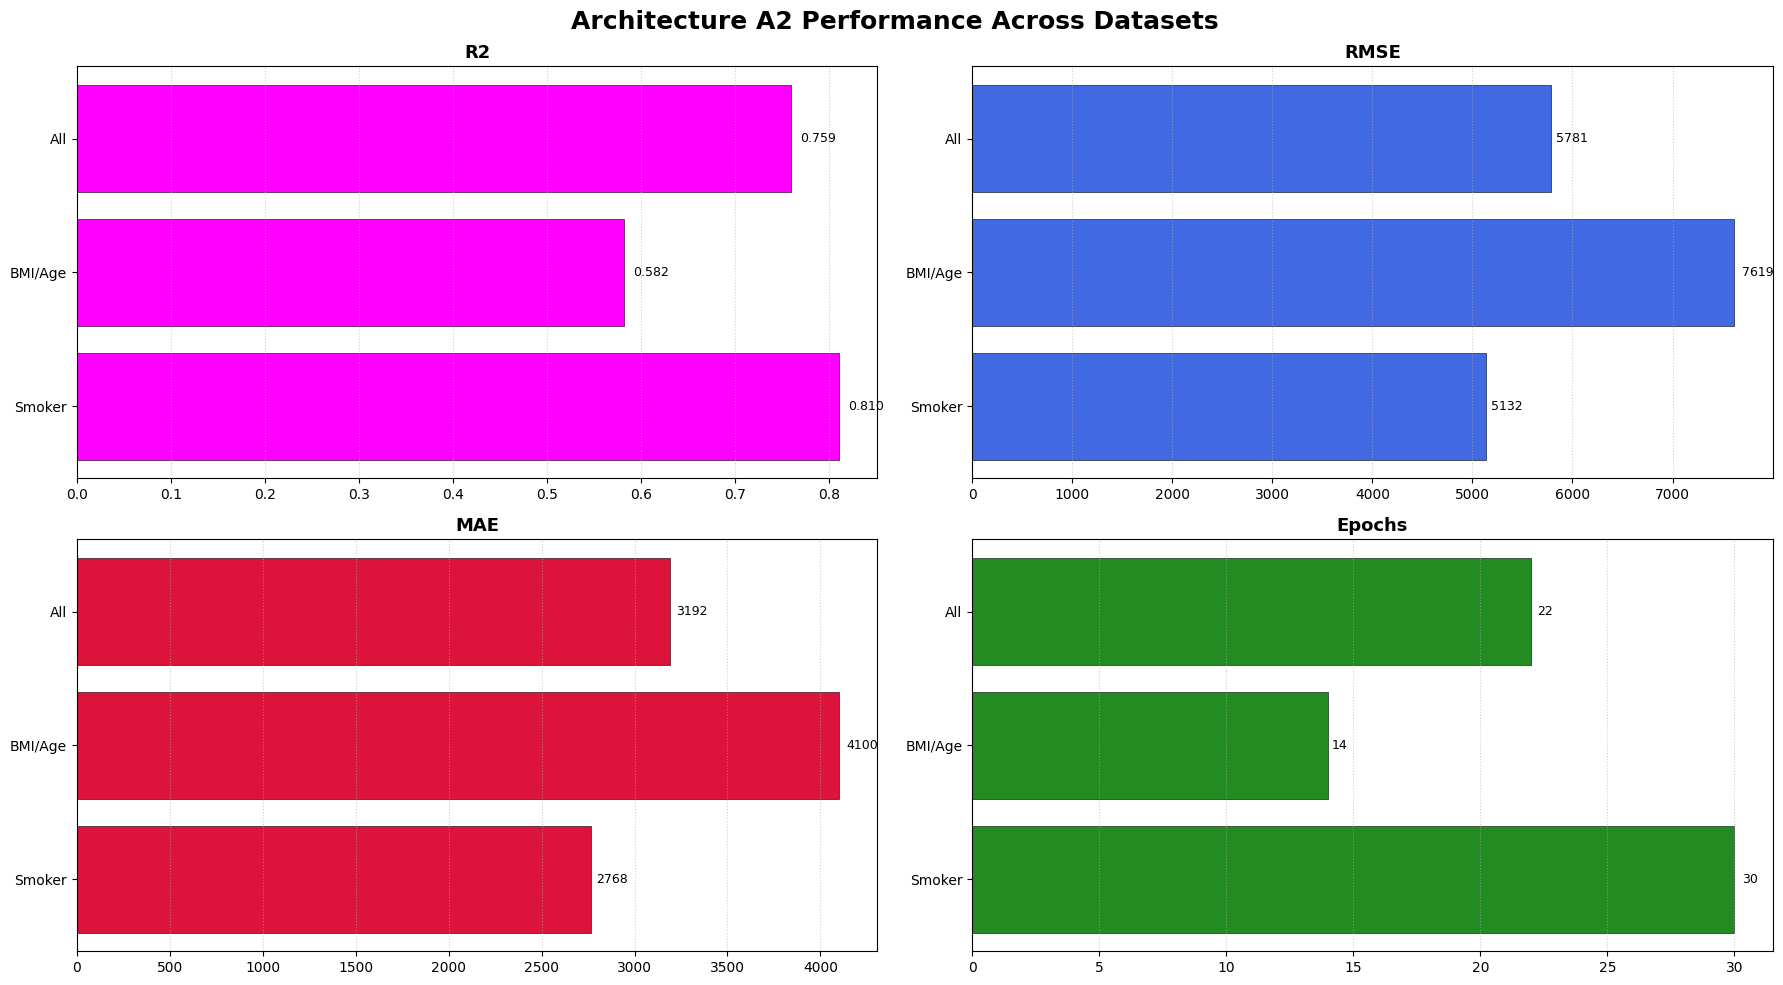

In [ ]:
# Stage 2 results saved into miscellaneous.py
from results_data import stage2_results as st2r

st2r_df = pd.DataFrame(st2r['A2'])

fig, axs = plt.subplots(2, 2, figsize=(18, 10))

metrics = ['R2', 'RMSE', 'MAE', 'Epochs']
colors = ['magenta', 'royalblue', 'crimson', 'forestgreen']

for ax, metric, color in zip(axs.flatten(), metrics, colors):

    bars = ax.barh(
        st2r_df.columns,
        st2r_df.loc[metric],
        color=color,
        edgecolor='black',
        linewidth=0.4
    )

    ax.set_title(metric, fontsize=13, weight='bold')
    ax.grid(axis='x', linestyle=':', alpha=0.6)

    for bar in bars:
        value = bar.get_width()

        ax.text(
            value + (0.01 if metric == 'R2' else value * 0.01),
            bar.get_y() + bar.get_height()/2,
            f'{value:.3f}' if metric == 'R2' else f'{value:.0f}',
            va='center',
            fontsize=9
        )

plt.suptitle(
    "Architecture A2 Performance Across Datasets",
    fontsize=18,
    weight='bold'
)

plt.tight_layout()
plt.show()

#### **STAGE 3:**

#### - Perform a few small refinements around the best model

In [18]:
# smoker eng
model_smoker_hyp_tun1, history_smoker_hyp_tun1 = architecture_benchmark(X_train_prep_smoker,
                                        y_train_log,
                                        X_val_prep_smoker,
                                        y_val_log,
                                        units_n=arch_a2,
                                        dout=0.1,
                                        epochs=40)

evaluation(model_smoker_hyp_tun1, X_val_prep_smoker, y_val_log, target_log=True)
print(f"number of epochs passed: {len(history_smoker_hyp_tun1.history['loss'])}")

6/6 - 0s - 10ms/step - loss: 0.1290 - mae: 0.1900
R²   : 0.8626
MAE  : 2150.18
RMSE : 4365.45
number of epochs passed: 29


In [ ]:
# smoker eng
model_smoker_hyp_tun2, history_smoker_hyp_tun2 = architecture_benchmark(X_train_prep_smoker,
                                        y_train_log,
                                        X_val_prep_smoker,
                                        y_val_log,
                                        units_n=arch_a2,
                                        dout=0.1,
                                        epochs=40,
                                        batch_size=48)

evaluation(model_smoker_hyp_tun2, X_val_prep_smoker, y_val_log, target_log=True)
print(f"number of epochs passed: {len(history_smoker_hyp_tun2.history['loss'])}")

6/6 - 0s - 14ms/step - loss: 0.1247 - mae: 0.2003
R²   : 0.8518
MAE  : 2346.82
RMSE : 4533.79
number of epochs passed: 35


In [156]:
# smoker eng
model_smoker_hyp_tun3, history_smoker_hyp_tun3 = architecture_benchmark(X_train_prep_smoker,
                                        y_train_log,
                                        X_val_prep_smoker,
                                        y_val_log,
                                        units_n=arch_a2,
                                        dout=0.05,
                                        epochs=40,
                                        batch_size=48)

evaluation(model_smoker_hyp_tun3, X_val_prep_smoker, y_val_log, target_log=True)
print(f"number of epochs passed: {len(history_smoker_hyp_tun3.history['loss'])}")

6/6 - 0s - 14ms/step - loss: 0.1269 - mae: 0.1842
R²   : 0.8551
MAE  : 2181.30
RMSE : 4483.12
number of epochs passed: 32


#### - Plot training history of the best arch-model

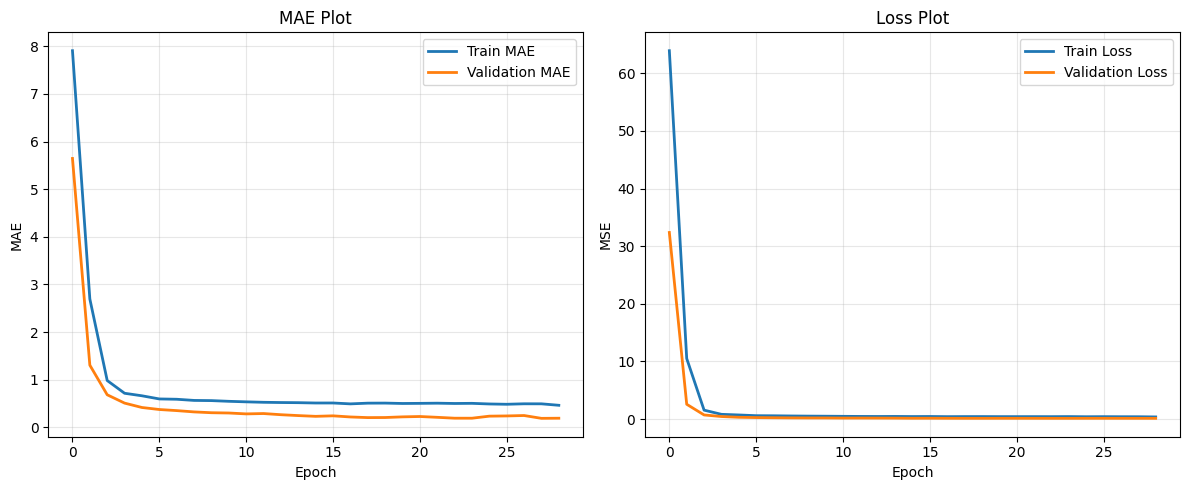

In [19]:
plot_training_history(history_smoker_hyp_tun1)

#### **The best architecture is:**
- Two hidden layers with 128, 64 units with ReLu activation function
- Dropout of 0.1
- Epochs of 40
- Batch size of 32
- Smoker-engineered-features dataset
- Log target (charges)

### 7) The final train on the full dataset (Smoker-eng)

#### - Combine and build the full dataset up

In [20]:
# Combine training and validation sets
X_final_train = np.vstack([
    X_train_prep_smoker,
    X_val_prep_smoker
])

y_final_train = np.concatenate([
    y_train_log,
    y_val_log
])

print("----- Combination of Training and Validation sets is done -----")
print(f"X_final_train shape: {X_final_train.shape}\ny_final_train shape: {y_final_train.shape}")

----- Combination of Training and Validation sets is done -----
X_final_train shape: (1137, 12)
y_final_train shape: (1137,)


#### - Perform the final training 

In [21]:
# Build Keras model with the right input shape
input_dim = X_final_train.shape[1]
# For fair arch comparison
tf.keras.utils.set_random_seed(RANDOM_STATE)

# Rebuild the final model
final_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(input_dim,)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.1),
    tf.keras.layers.Dense(1, activation='linear')
])

# Compile
final_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Stop early if validation loss doesn’t improve for 5 epochs
early_stop_final_model = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train on full data – use a validation split for early stopping (no separate set)
history_final = final_model.fit(
    X_final_train,
    y_final_train,
    epochs=40,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop_final_model]
)


Epoch 1/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 62.0822 - mae: 7.7762 - val_loss: 29.9576 - val_mae: 5.4259
Epoch 2/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 8.7894 - mae: 2.4076 - val_loss: 2.0580 - val_mae: 1.1748
Epoch 3/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.5097 - mae: 0.9731 - val_loss: 0.6682 - val_mae: 0.6592
Epoch 4/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.8913 - mae: 0.7315 - val_loss: 0.3927 - val_mae: 0.4731
Epoch 5/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6826 - mae: 0.6361 - val_loss: 0.2676 - val_mae: 0.3881
Epoch 6/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6009 - mae: 0.5983 - val_loss: 0.2154 - val_mae: 0.3474
Epoch 7/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5972 - mae: 0.5903 - val_loss: 0.1863 - val_mae: 0.3158
Epoch 8/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5658 - mae: 0.5726 - val_loss: 0.1687 - val_mae: 0.2905
Epoch 9/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5303 - m

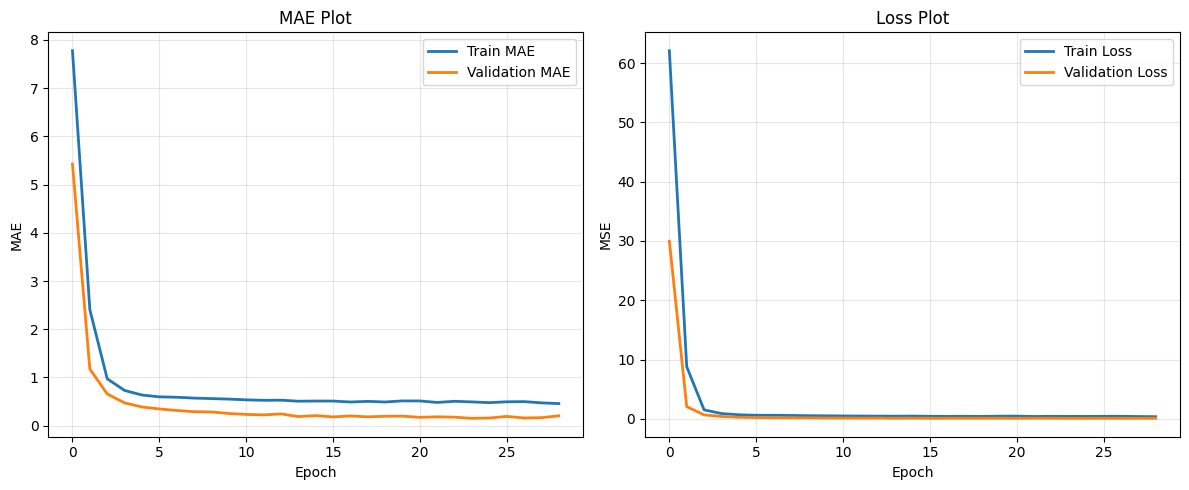

In [22]:
# Plot training history of the final model
plot_training_history(history_final)


### 8) The final evaluation on test set

In [30]:
# Predict on the test set
y_pred_test_ = final_model.predict(X_test_prep_smoker)

# Back-transform
y_pred_test = np.expm1(y_pred_test_).flatten()
y_true_test = np.expm1(y_test_log)

# Metrics
r2 = r2_score(y_true_test, y_pred_test)
mae = mean_absolute_error(y_true_test, y_pred_test)
rmse = root_mean_squared_error(y_true_test, y_pred_test)

print("Results of evaluation on the test set:")
print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Results of evaluation on the test set:
R²   : 0.8425
MAE  : 2278.55
RMSE : 4897.56


### 9) Visualizations on the final model

#### -  Plot predicted vs actual (test set)

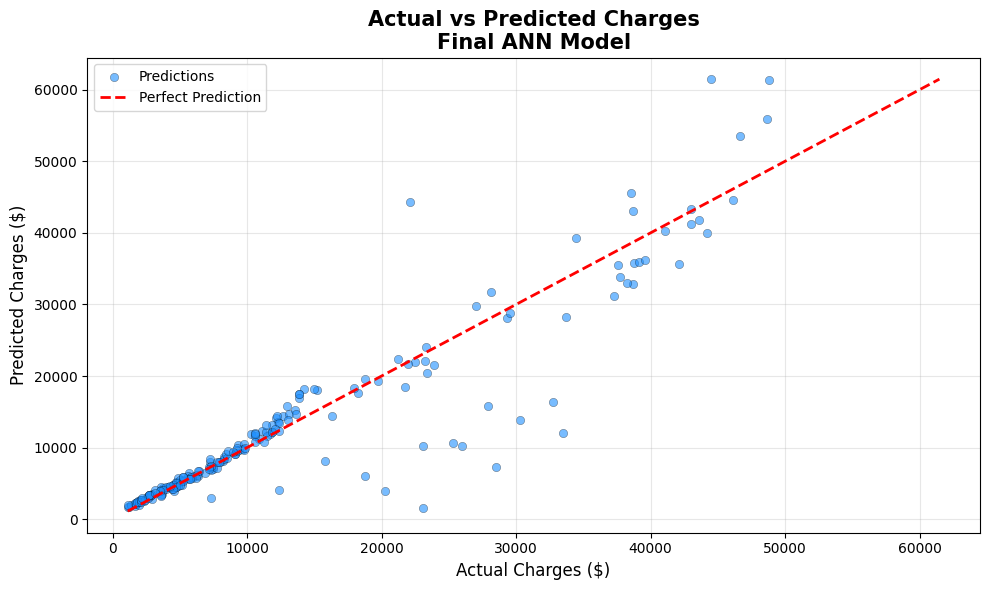

In [31]:
plt.figure(figsize=(10,6))

plt.scatter(
    y_true_test,
    y_pred_test,
    alpha=0.6,
    color='dodgerblue',
    edgecolor='black',
    linewidth=0.3,
    label='Predictions'
)

lims = [
    min(y_true_test.min(), y_pred_test.min()),
    max(y_true_test.max(), y_pred_test.max())
]

plt.plot(
    lims,
    lims,
    'r--',
    linewidth=2,
    label='Perfect Prediction'
)

plt.xlabel("Actual Charges ($)", fontsize=12)
plt.ylabel("Predicted Charges ($)", fontsize=12)

plt.title(
    "Actual vs Predicted Charges\nFinal ANN Model",
    fontsize=15,
    weight='bold'
)

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

#### - Residual plot

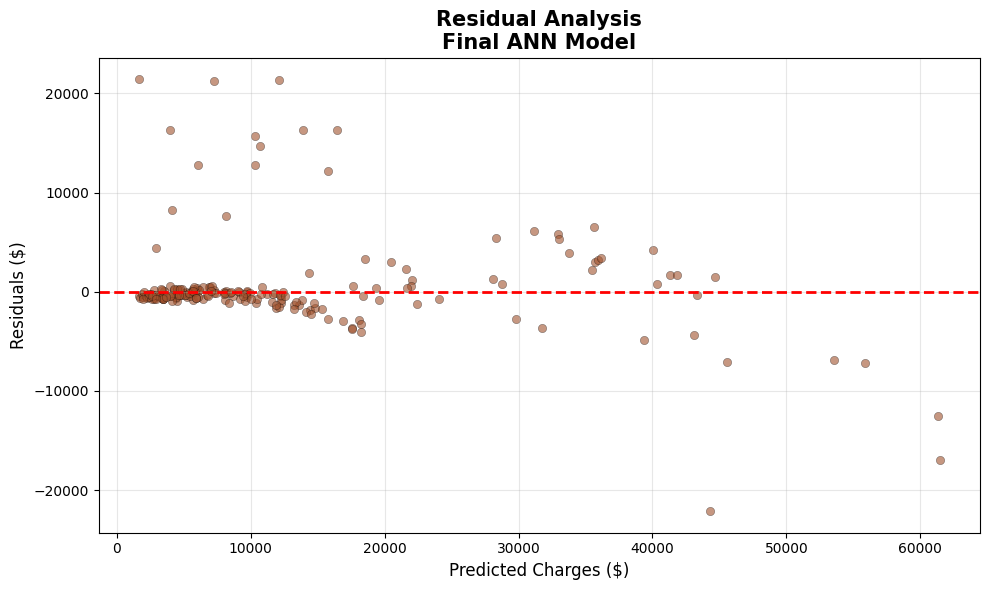

In [32]:
residuals = y_true_test - y_pred_test

plt.figure(figsize=(10,6))

plt.scatter(
    y_pred_test,
    residuals,
    alpha=0.6,
    color='sienna',
    edgecolor='black',
    linewidth=0.3
)

plt.axhline(
    0,
    color='red',
    linestyle='--',
    linewidth=2
)

plt.xlabel("Predicted Charges ($)", fontsize=12)
plt.ylabel("Residuals ($)", fontsize=12)

plt.title(
    "Residual Analysis\nFinal ANN Model",
    fontsize=15,
    weight='bold'
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [64]:
#--------------------------------------------
# Save the model & preprocessing pipeline
#--------------------------------------------

# Save the preprocessor (Smoker)
joblib.dump(preprocessor_smoker, PROJECT_ROOT / "Models/Regression/ANN_insurance_preprocessor.joblib")
# Save the model
final_model.save(PROJECT_ROOT / "Models/Regression/ANN_insurance_model.keras")

print("Model Saved: ANN_insurance_model.keras",
       "Preprocessor Saved: ANN_insurance_preprocessor.joblib",
       sep="    |   ")


Model Saved: ANN_insurance_model.keras    |   Preprocessor Saved: ANN_insurance_preprocessor.joblib


## Conclusion – Insurance Charges Regression Using Artificial Neural Networks

In this notebook, an Artificial Neural Network (ANN) framework was developed to predict individual medical insurance charges using demographic and lifestyle information from the Insurance dataset.

Several preprocessing and feature-engineering strategies were evaluated, including smoking-related interaction features, BMI/age-derived variables, and a combined engineered feature set. In addition, both raw and logarithm-transformed target variables were investigated.

Initial experiments demonstrated that predicting the raw target directly resulted in poor convergence and weak predictive performance. In contrast, applying a logarithmic transformation to the target substantially improved model stability, optimization behavior, and predictive accuracy. Consequently, all subsequent architecture experiments were performed using the log-transformed target.

A series of neural-network architectures with varying depth and width were benchmarked. The strongest performance was achieved using the smoking-engineered dataset together with a two-hidden-layer architecture consisting of 128 and 64 neurons. Additional refinements involving dropout reduction and training adjustments further improved validation performance.

The final model was trained on the combined training and validation data and evaluated once on the independent test set. The model achieved:

* R² ≈ 0.84
* MAE ≈ $2,279
* RMSE ≈ $4,898

These results demonstrate that the ANN successfully learned the underlying relationships within the dataset and generalized well to unseen observations.

### Key Take-Away

This study highlights an important practical lesson in applied machine learning: increasing model complexity does not necessarily guarantee superior predictive performance. Although the neural network achieved strong results, its performance remained comparable to that of the best classical machine-learning model developed in the previous notebook.

Together, the classical machine-learning and ANN experiments provide a comprehensive comparison of linear, ensemble-based, and deep-learning approaches for tabular healthcare-related regression problems. The workflow demonstrated the complete predictive modeling pipeline, including preprocessing, feature engineering, architecture design, model selection, validation, final testing, and model interpretation.
